In [1]:
%pip install langchain langchain-community pypdf2 python-dotenv openai tiktoken

Note: you may need to restart the kernel to use updated packages.


#### Step 1: Setup and Data Loading

In [5]:
%pip install -q langchain langchain-community pypdf2 python-dotenv openai tiktoken

%pip install -q langchain langchain-community pypdf2 python-dotenv openai tiktoken

import os
import subprocess
from pathlib import Path

from dotenv import load_dotenv
from PyPDF2 import PdfReader
from openai import OpenAI

load_dotenv()

print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))

# Paths
podcast_audio_path = Path("resources/podcast.m4a")
pdf_path = Path("resources/trustworthy_ai.pdf")
compressed_audio_path = Path("resources/podcast_small.m4a")

# Load PDF text
pdf_text = ""
if pdf_path.exists():
    reader = PdfReader(str(pdf_path))
    pdf_text = "\n".join(page.extract_text() or "" for page in reader.pages)
    print(f"PDF loaded: {pdf_path} | characters: {len(pdf_text)}")
else:
    print(f"PDF file not found: {pdf_path}")

# Load/transcribe podcast audio
podcast_text = ""
if podcast_audio_path.exists():
    audio_to_transcribe = podcast_audio_path

    # OpenAI transcription uploads are limited to 25 MB, so compress if needed
    if podcast_audio_path.stat().st_size > 25 * 1024 * 1024:
        print("Audio is over 25 MB, compressing before transcription...")
        subprocess.run([
            "ffmpeg",
            "-y",
            "-i", str(podcast_audio_path),
            "-ac", "1",
            "-ar", "16000",
            "-b:a", "64k",
            str(compressed_audio_path)
        ], check=True)
        audio_to_transcribe = compressed_audio_path
        print(f"Compressed audio created: {audio_to_transcribe}")

    client = OpenAI()
    with open(audio_to_transcribe, "rb") as audio_file:
        transcription = client.audio.transcriptions.create(
            model="whisper-1",
            file=audio_file
        )
    podcast_text = transcription.text
    print(f"Podcast transcribed: {audio_to_transcribe} | characters: {len(podcast_text)}")
else:
    print(f"Podcast file not found: {podcast_audio_path}")

print("Step 1 complete.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
OPENAI_API_KEY set: True
PDF loaded: resources/trustworthy_ai.pdf | characters: 158078
Audio is over 25 MB, compressing before transcription...


ffmpeg version 8.1.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.101 / 60. 26.101
  libavcodec     62. 28.101 / 62. 28.101
  libavformat    62. 12.101 / 62. 12.101
  libavdevice    62.  3.101 / 62.  3.101
  libavfilter    11. 14.101 / 11. 14.101
  libswscale      9.  5.101 /  9.  5.101
  libswresample   6.  3.101 /  6.  3.101
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'resources/podcast.m4a':
  Metadata:
    major_brand     : dash
    minor_version   : 0
    compatible_brands: iso6mp41
    creation_time   : 2026-

Compressed audio created: resources/podcast_small.m4a
Podcast transcribed: resources/podcast_small.m4a | characters: 16407
Step 1 complete.


#### Step 2: Implement Fixed-Size Chunking

In [6]:
from langchain_text_splitters import CharacterTextSplitter
from textwrap import shorten

# Assumes pdf_text and podcast_text already exist from step 1

def chunk_report(text, label, chunk_size, chunk_overlap):
    splitter = CharacterTextSplitter(
        separator="",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = splitter.split_text(text)

    print(f"\n{label} | chunk_size={chunk_size} | overlap={chunk_overlap}")
    print(f"Total chunks: {len(chunks)}")

    for i, chunk in enumerate(chunks[:3], start=1):
        preview = shorten(chunk.replace("\n", " "), width=140, placeholder="...")
        print(f"Chunk {i} | chars={len(chunk)} | preview={preview}")

    if len(chunks) > 1:
        print("Last chunk preview:")
        print(shorten(chunks[-1].replace("\n", " "), width=140, placeholder="..."))

    return chunks

settings = [
    (500, 0),
    (500, 50),
    (500, 100),
    (1000, 0),
    (1000, 50),
    (1000, 100),
    (2000, 0),
    (2000, 50),
    (2000, 100),
]

results = {}

for chunk_size, overlap in settings:
    results[("pdf", chunk_size, overlap)] = chunk_report(
        pdf_text, "PDF", chunk_size, overlap
    )
    results[("podcast", chunk_size, overlap)] = chunk_report(
        podcast_text, "Podcast", chunk_size, overlap
    )


PDF | chunk_size=500 | overlap=0
Total chunks: 317
Chunk 1 | chars=489 | preview=INDEPENDENT HIGH-LEVEL EXPERT GROUP ON ARTIFICIAL INTELLIGENCE SET UP BY THE EUROPEAN COMMISSION ETHICS GUIDELINES FOR TRUSTWORTHY AI...
Chunk 2 | chars=500 | preview=, although they do not necessarily agree with every single statement in the document . The Trustworthy AI assessment list presented in...
Chunk 3 | chars=500 | preview=pean Commission in June 2018. Contact Nathalie Smuha - AI HLEG Coordinator E-mail CNECT -HLG-AI@ec.europa.eu European Commission B-1049...
Last chunk preview:
content of this document . Nathalie Smuha provided editorial support.

Podcast | chunk_size=500 | overlap=0
Total chunks: 33
Chunk 1 | chars=500 | preview=So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get...
Chunk 2 | chars=500 | preview=t the algorithm that just denied your mortgage application or the AI system scanning your face at th

##### Analysis questions

1. Does fixed-size chunking break sentences in the middle?

Yes.

We can see chunks starting with fragments like , although..., pean Commission..., t the algorithm..., eavy hitter...
The smaller the chunk size, the more likely it is to cut a sentence or word in half.

2. How does it handle paragraph boundaries?

Fixed-size chunking ignores paragraph structure completely.
In the PDF, this is especially visible because the document has headings, footnotes, and formal sections, but the chunks slice through all of that.
In the podcast transcript, it also ignores conversational turns and natural pauses, so a speaker’s thought can be split across chunks.

3. Which content type handles fixed-size chunking better?

The podcast transcript handles it a bit better than the PDF.

The transcript is already a more linear, conversational stream of text.
Even if it gets split mid-sentence, the meaning is often still easier to recover.
The PDF is more structured and benefits more from boundary-aware splitting, so fixed-size chunking damages it more.

What the output also shows overall:
-The PDF produces far more chunks than the podcast at every size because the PDF text is much longer.
-Increasing overlap from 0 to 50 to 100 increases chunk count slightly, as expected.
-Larger chunk sizes like 1000 and 2000 reduce the number of chunks and usually preserve more context, but they still break at arbitrary points.

#### Step 3: Implement Recursive Character Chunking

In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from textwrap import shorten

# Assumes pdf_text and podcast_text already exist from step 1

def recursive_chunk_report(text, label, chunk_size, chunk_overlap):
    recursive_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", ". ", " ", ""]
    )

    chunks = recursive_splitter.split_text(text)

    print(f"\n{label} | recursive | chunk_size={chunk_size} | overlap={chunk_overlap}")
    print(f"Total chunks: {len(chunks)}")

    for i, chunk in enumerate(chunks[:3], start=1):
        preview = shorten(chunk.replace("\n", " "), width=140, placeholder="...")
        print(f"Chunk {i} | chars={len(chunk)} | preview={preview}")

    if len(chunks) > 1:
        print("Last chunk preview:")
        print(shorten(chunks[-1].replace("\n", " "), width=140, placeholder="..."))

    return chunks

settings = [
    (500, 0),
    (500, 100),
    (1000, 200),
    (2000, 200),
]

recursive_results = {}

for chunk_size, overlap in settings:
    recursive_results[("pdf", chunk_size, overlap)] = recursive_chunk_report(
        pdf_text, "PDF", chunk_size, overlap
    )
    recursive_results[("podcast", chunk_size, overlap)] = recursive_chunk_report(
        podcast_text, "Podcast", chunk_size, overlap
    )


PDF | recursive | chunk_size=500 | overlap=0
Total chunks: 352
Chunk 1 | chars=383 | preview=INDEPENDENT HIGH-LEVEL EXPERT GROUP ON ARTIFICIAL INTELLIGENCE SET UP BY THE EUROPEAN COMMISSION ETHICS GUIDELINES FOR TRUSTWORTHY AI...
Chunk 2 | chars=419 | preview=named in this document support the overall framework for Trustworthy AI put forward in these Guidelines, although they do not necessarily...
Chunk 3 | chars=497 | preview=feedback gathered through the piloting phase, will be presented to the Eu ropean Commission in early 2020. The AI HLEG is an independent...
Last chunk preview:
Nathalie Smuha provided editorial support.

Podcast | recursive | chunk_size=500 | overlap=0
Total chunks: 35
Chunk 1 | chars=488 | preview=So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get...
Chunk 2 | chars=499 | preview=. Think about the algorithm that just denied your mortgage application or the AI system scanning yo

##### Analysis questions:

1. Does recursive chunking preserve sentence boundaries better?

Yes, noticeably better.

Chunks now tend to start at sentence boundaries or close to them, rather than mid-word fragments.
You still see a few chunk starts like . Think about... or . This is a heavy hitter..., which means it is not perfect, but it is clearly better than arbitrary character splitting.

2. How does it handle the podcast's conversational structure?

The podcast chunks keep more of the natural spoken flow.
In the output, chunks often preserve a coherent speaker turn or a complete idea before moving on.
This matters more for the transcript than for the PDF because the transcript is already conversational and recursive splitting respects that rhythm better than fixed-size chunking.

3. Does it respect PDF section headers?

Not fully.

Recursive splitting does better than fixed-size chunking because it tries paragraph and newline boundaries first.
In the PDF, you can see some chunks beginning with structured document language and section-like text rather than random cutoffs.
But it still does not reliably keep section headers attached to the following content. Some headings are still separated or mixed into nearby text.

#### Step 4: Implement Token-Based Chunking

In [8]:
from langchain_text_splitters import TokenTextSplitter
import tiktoken
from textwrap import shorten

# Assumes pdf_text and podcast_text already exist from step 1

encoding = tiktoken.get_encoding("cl100k_base")

settings = [
    (500, 50),
    (1000, 50),
]

token_results = {}

for chunk_size, chunk_overlap in settings:
    token_splitter = TokenTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    pdf_chunks_tokens = token_splitter.split_text(pdf_text)
    podcast_chunks_tokens = token_splitter.split_text(podcast_text)

    token_results[("pdf", chunk_size, chunk_overlap)] = pdf_chunks_tokens
    token_results[("podcast", chunk_size, chunk_overlap)] = podcast_chunks_tokens

    print(f"\nToken chunking | chunk_size={chunk_size} | overlap={chunk_overlap}")
    print(f"PDF: {len(pdf_chunks_tokens)} chunks")
    print(f"Podcast: {len(podcast_chunks_tokens)} chunks")

    print("\nPDF sample chunks:")
    for i, chunk in enumerate(pdf_chunks_tokens[:3], start=1):
        token_count = len(encoding.encode(chunk))
        preview = shorten(chunk.replace("\n", " "), width=140, placeholder="...")
        print(f"Chunk {i}: {token_count} tokens, {len(chunk)} characters | {preview}")

    print("\nPodcast sample chunks:")
    for i, chunk in enumerate(podcast_chunks_tokens[:3], start=1):
        token_count = len(encoding.encode(chunk))
        preview = shorten(chunk.replace("\n", " "), width=140, placeholder="...")
        print(f"Chunk {i}: {token_count} tokens, {len(chunk)} characters | {preview}")


Token chunking | chunk_size=500 | overlap=50
PDF: 85 chunks
Podcast: 8 chunks

PDF sample chunks:
Chunk 1: 404 tokens, 1788 characters | INDEPENDENT HIGH-LEVEL EXPERT GROUP ON ARTIFICIAL INTELLIGENCE SET UP BY THE EUROPEAN COMMISSION ETHICS GUIDELINES FOR TRUSTWORTHY AI...
Chunk 2: 405 tokens, 1647 characters | version. Neither the European Commission nor any person acting on behalf of the Commission is responsible for the use which might be made...
Chunk 3: 461 tokens, 2092 characters | AI 32 D. CONCLUSION 35 GLOSSARY 36 2 EXECUTIVE SUMMARY The aim of the Guideline s is to promot e Trustworthy AI. Trustworthy AI has three...

Podcast sample chunks:
Chunk 1: 501 tokens, 2314 characters | So imagine for a second you're driving across, I don't know, a massive suspension bridge. Okay. You don't pull over halfway across, get...
Chunk 2: 499 tokens, 2300 characters | . And a checklist that every developer should probably have tattooed on their arm. Okay, let's start with the big picture. T

##### Conclusion:

Token-based chunking is better aligned with LLM context windows than character-based chunking. The same token size maps to very different character lengths across the PDF and podcast, which shows why character counts are only an approximation. The podcast chunks are fewer because the transcript is shorter, while the PDF produces more chunks due to its greater length and denser structure. Overall, token chunking is the most practical strategy so far for retrieval-oriented LLM workflows.

#### Step 5: Semantic Chunking (Optional - Advanced)

In [9]:
%pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np
import re
from textwrap import shorten

# Assumes pdf_text already exists from step 1
pdf_sample = pdf_text[:5000]  # keep it small for this optional step

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def semantic_chunk(text, threshold=0.7):
    # Simple sentence split that keeps punctuation attached to the sentence
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    sentences = [s for s in sentences if s]

    if len(sentences) < 2:
        return [text]

    embeddings = model.encode(sentences, normalize_embeddings=True)

    chunks = []
    current_chunk = [sentences[0]]

    for i in range(1, len(sentences)):
        similarity = float(np.dot(embeddings[i - 1], embeddings[i]))

        if similarity < threshold:
            chunks.append(" ".join(current_chunk))
            current_chunk = [sentences[i]]
        else:
            current_chunk.append(sentences[i])

    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

pdf_chunks_semantic = semantic_chunk(pdf_sample, threshold=0.7)

print(f"Semantic chunks from sample: {len(pdf_chunks_semantic)}")
for i, chunk in enumerate(pdf_chunks_semantic[:5], start=1):
    preview = shorten(chunk.replace("\n", " "), width=140, placeholder="...")
    print(f"Chunk {i} | chars={len(chunk)} | preview={preview}")

Note: you may need to restart the kernel to use updated packages.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic chunks from sample: 29
Chunk 1 | chars=576 | preview=INDEPENDENT HIGH-LEVEL EXPERT GROUP ON ARTIFICIAL INTELLIGENCE SET UP BY THE EUROPEAN COMMISSION ETHICS GUIDELINES FOR TRUSTWORTHY AI...
Chunk 2 | chars=155 | preview=The Trustworthy AI assessment list presented in Chapter III of this document will undergo a piloting phase by stakeholders to gather...
Chunk 3 | chars=175 | preview=A revised version of the assessment list, taking into account the feedback gathered through the piloting phase, will be presented to the...
Chunk 4 | chars=99 | preview=The AI HLEG is an independent expert group that was set up by the European Commission in June 2018.
Chunk 5 | chars=166 | preview=Contact Nathalie Smuha - AI HLEG Coordinator E-mail CNECT -HLG-AI@ec.europa.eu European Commission B-1049 Brussels Document made public...


##### Conclusion:

Semantic chunking produced many small, meaning-based chunks rather than uniform-size chunks. The output suggests it is sensitive to topic shifts in the PDF and can separate sections more naturally than fixed-size methods. However, some chunks are very short, which means the threshold may be a bit strict and could be adjusted to reduce over-splitting.

#### Step 6: Visualize and Compare Results

,document,strategy,chunk_size,overlap,chunks,avg_chars,min_chars,max_chars,avg_words,sentence_end_rate,mid_sentence_start_rate,paragraph_break_rate
0,pdf,fixed,500,0.0,317,497.356467,73,500,76.842271,0.025237,0.917981,0.009464
2,pdf,fixed,500,50.0,352,497.446023,124,500,76.985795,0.017045,0.914773,0.008523
4,pdf,fixed,500,100.0,395,497.746835,323,500,77.022785,0.022785,0.929114,0.010127
6,pdf,fixed,1000,0.0,159,992.490566,73,1000,152.584906,0.031447,0.918239,0.018868
8,pdf,fixed,1000,50.0,167,994.802395,374,1000,152.724551,0.053892,0.898204,0.017964
10,pdf,fixed,1000,100.0,176,996.000000,574,1000,153.096591,0.017045,0.903409,0.017045
12,pdf,fixed,2000,0.0,80,1975.462500,73,2000,302.712500,0.050000,0.937500,0.037500
14,pdf,fixed,2000,50.0,82,1976.646341,124,2000,302.914634,0.024390,0.914634,0.036585
16,pdf,fixed,2000,100.0,84,1979.011905,374,2000,303.250000,0.023810,0.880952,0.035714
18,pdf,recursive,500,0.0,352,443.420455,42,498,68.616477,0.247159,0.596591,0.000000


/var/folders/nd/rjcc5q017nn8v9hp740b83gc0000gp/T/ipykernel_83539/2733025483.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=box_labels, showfliers=False)


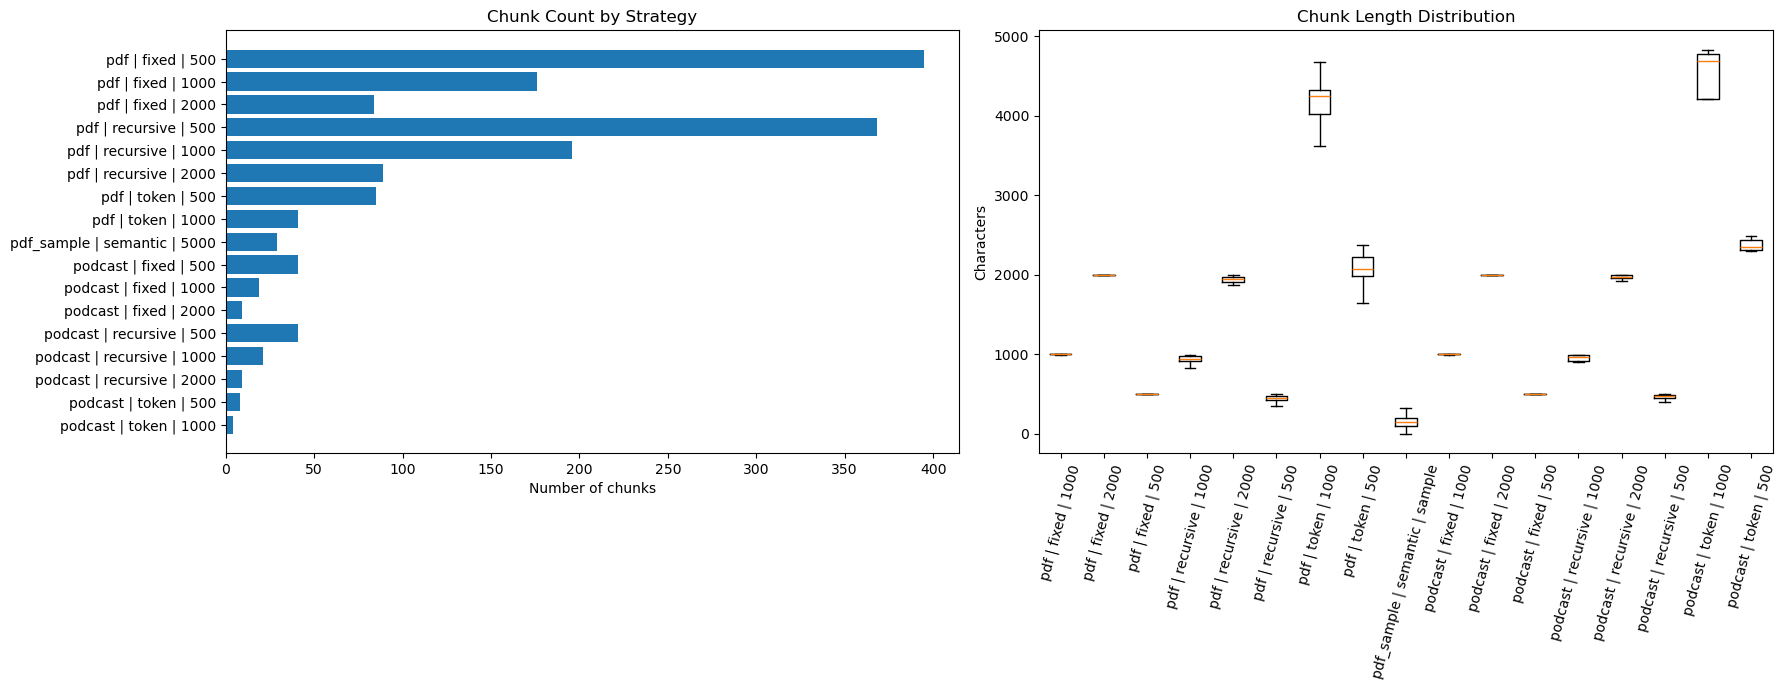


Trade-off summary:
- Fixed-size: simplest, but most likely to cut sentences and ignore structure.
- Recursive: better structure preservation, especially for the PDF.
- Token-based: best match for LLM context windows and retrieval budgets.
- Semantic: most meaning-aware, but more variable and computationally heavier.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict

def build_summary_row(document, strategy, chunk_size, overlap, chunks):
    lengths = [len(c) for c in chunks]
    word_lengths = [len(c.split()) for c in chunks]
    return {
        "document": document,
        "strategy": strategy,
        "chunk_size": chunk_size,
        "overlap": overlap,
        "chunks": len(chunks),
        "avg_chars": sum(lengths) / len(lengths) if lengths else 0,
        "min_chars": min(lengths) if lengths else 0,
        "max_chars": max(lengths) if lengths else 0,
        "avg_words": sum(word_lengths) / len(word_lengths) if word_lengths else 0,
    }

def quality_metrics(chunks):
    if not chunks:
        return {
            "sentence_end_rate": 0,
            "mid_sentence_start_rate": 0,
            "paragraph_break_rate": 0,
        }

    sentence_end_rate = sum(c.strip().endswith((".", "?", "!")) for c in chunks) / len(chunks)

    # Heuristic: if a chunk starts with lowercase or punctuation, it likely begins mid-sentence
    mid_sentence_start_rate = 0
    for c in chunks:
        stripped = c.lstrip()
        if not stripped:
            continue
        first = re.search(r"[A-Za-z]", stripped)
        if first:
            first_char = first.group(0)
            if first_char.islower():
                mid_sentence_start_rate += 1
        else:
            mid_sentence_start_rate += 1
    mid_sentence_start_rate /= len(chunks)

    # Heuristic: chunks that preserve paragraph structure often still contain paragraph breaks
    # This is not perfect, but it helps compare structure-aware vs blind splitting.
    paragraph_break_rate = sum("\n\n" in c for c in chunks) / len(chunks)

    return {
        "sentence_end_rate": sentence_end_rate,
        "mid_sentence_start_rate": mid_sentence_start_rate,
        "paragraph_break_rate": paragraph_break_rate,
    }

summary_rows = []
length_rows = []

# Fixed-size
for (doc, chunk_size, overlap), chunks in results.items():
    row = build_summary_row(doc, "fixed", chunk_size, overlap, chunks)
    row.update(quality_metrics(chunks))
    summary_rows.append(row)

    for c in chunks:
        length_rows.append({
            "document": doc,
            "strategy": "fixed",
            "chunk_size": chunk_size,
            "overlap": overlap,
            "chars": len(c),
            "label": f"{doc} | fixed | {chunk_size}"
        })

# Recursive
for (doc, chunk_size, overlap), chunks in recursive_results.items():
    row = build_summary_row(doc, "recursive", chunk_size, overlap, chunks)
    row.update(quality_metrics(chunks))
    summary_rows.append(row)

    for c in chunks:
        length_rows.append({
            "document": doc,
            "strategy": "recursive",
            "chunk_size": chunk_size,
            "overlap": overlap,
            "chars": len(c),
            "label": f"{doc} | recursive | {chunk_size}"
        })

# Token
for (doc, chunk_size, overlap), chunks in token_results.items():
    row = build_summary_row(doc, "token", chunk_size, overlap, chunks)
    row.update(quality_metrics(chunks))
    summary_rows.append(row)

    for c in chunks:
        length_rows.append({
            "document": doc,
            "strategy": "token",
            "chunk_size": chunk_size,
            "overlap": overlap,
            "chars": len(c),
            "label": f"{doc} | token | {chunk_size}"
        })

# Semantic sample
row = build_summary_row("pdf_sample", "semantic", 5000, None, pdf_chunks_semantic)
row.update(quality_metrics(pdf_chunks_semantic))
summary_rows.append(row)

for c in pdf_chunks_semantic:
    length_rows.append({
        "document": "pdf_sample",
        "strategy": "semantic",
        "chunk_size": 5000,
        "overlap": None,
        "chars": len(c),
        "label": "pdf_sample | semantic | sample"
    })

summary_df = pd.DataFrame(summary_rows)
length_df = pd.DataFrame(length_rows)

summary_df = summary_df[[
    "document", "strategy", "chunk_size", "overlap",
    "chunks", "avg_chars", "min_chars", "max_chars",
    "avg_words", "sentence_end_rate", "mid_sentence_start_rate", "paragraph_break_rate"
]].sort_values(["document", "strategy", "chunk_size"])

display(summary_df)

# ---- Visualizations ----
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_df = summary_df.copy()
plot_df["group"] = plot_df["document"] + " | " + plot_df["strategy"] + " | " + plot_df["chunk_size"].astype(str)

axes[0].barh(plot_df["group"], plot_df["chunks"])
axes[0].set_title("Chunk Count by Strategy")
axes[0].set_xlabel("Number of chunks")
axes[0].invert_yaxis()

box_labels = []
box_data = []

for label, group in length_df.groupby("label"):
    box_labels.append(label)
    box_data.append(group["chars"].tolist())

axes[1].boxplot(box_data, labels=box_labels, showfliers=False)
axes[1].set_title("Chunk Length Distribution")
axes[1].set_ylabel("Characters")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

# ---- Short trade-off summary ----
print("\nTrade-off summary:")
print("- Fixed-size: simplest, but most likely to cut sentences and ignore structure.")
print("- Recursive: better structure preservation, especially for the PDF.")
print("- Token-based: best match for LLM context windows and retrieval budgets.")
print("- Semantic: most meaning-aware, but more variable and computationally heavier.")

#### Step 7: Analyze Chunk Quality

In [12]:
import pandas as pd
import re

def first_alpha(chunk):
    m = re.search(r"[A-Za-z]", chunk)
    return m.group(0) if m else ""

def sentence_quality(chunks):
    if not chunks:
        return {
            "sentence_end_rate": 0,
            "mid_sentence_start_rate": 0,
            "mid_sentence_break_rate": 0,
        }

    ends_cleanly = sum(c.strip().endswith((".", "?", "!", ":", ";")) for c in chunks) / len(chunks)

    starts_mid_sentence = 0
    for c in chunks:
        s = c.lstrip()
        if not s:
            starts_mid_sentence += 1
            continue
        ch = first_alpha(s)
        if not ch:
            starts_mid_sentence += 1
        elif ch.islower():
            starts_mid_sentence += 1

    starts_mid_sentence /= len(chunks)

    # Rough signal: if a chunk neither ends cleanly nor begins cleanly, it likely cuts through content.
    mid_sentence_break_rate = sum(
        (not c.strip().endswith((".", "?", "!", ":", ";"))) and
        (first_alpha(c.lstrip()).islower() if first_alpha(c.lstrip()) else True)
        for c in chunks
    ) / len(chunks)

    return {
        "sentence_end_rate": ends_cleanly,
        "mid_sentence_start_rate": starts_mid_sentence,
        "mid_sentence_break_rate": mid_sentence_break_rate,
    }

def paragraph_quality(chunks):
    if not chunks:
        return {
            "paragraph_break_rate": 0,
            "paragraph_inside_rate": 0,
        }

    paragraph_break_rate = sum(("\n\n" in c) for c in chunks) / len(chunks)

    # Another rough signal: chunks that start or end with a newline are often aligned with paragraph boundaries.
    paragraph_edge_rate = sum(
        c.startswith("\n") or c.endswith("\n") or c.startswith("\n\n") or c.endswith("\n\n")
        for c in chunks
    ) / len(chunks)

    return {
        "paragraph_break_rate": paragraph_break_rate,
        "paragraph_edge_rate": paragraph_edge_rate,
    }

quality_rows = []

# Fixed-size
for (doc, chunk_size, overlap), chunks in results.items():
    row = {
        "document": doc,
        "strategy": "fixed",
        "chunk_size": chunk_size,
        "overlap": overlap,
        **sentence_quality(chunks),
        **paragraph_quality(chunks),
    }
    quality_rows.append(row)

# Recursive
for (doc, chunk_size, overlap), chunks in recursive_results.items():
    row = {
        "document": doc,
        "strategy": "recursive",
        "chunk_size": chunk_size,
        "overlap": overlap,
        **sentence_quality(chunks),
        **paragraph_quality(chunks),
    }
    quality_rows.append(row)

# Token
for (doc, chunk_size, overlap), chunks in token_results.items():
    row = {
        "document": doc,
        "strategy": "token",
        "chunk_size": chunk_size,
        "overlap": overlap,
        **sentence_quality(chunks),
        **paragraph_quality(chunks),
    }
    quality_rows.append(row)

# Semantic sample
quality_rows.append({
    "document": "pdf_sample",
    "strategy": "semantic",
    "chunk_size": 5000,
    "overlap": None,
    **sentence_quality(pdf_chunks_semantic),
    **paragraph_quality(pdf_chunks_semantic),
})

quality_df = pd.DataFrame(quality_rows)

quality_df = quality_df[[
    "document", "strategy", "chunk_size", "overlap",
    "sentence_end_rate", "mid_sentence_start_rate", "mid_sentence_break_rate",
    "paragraph_break_rate", "paragraph_edge_rate"
]].sort_values(["document", "strategy", "chunk_size"])

display(quality_df)

# Simple best-context summary
print("\nBest context-preserving strategy by document (heuristic):")

for doc in quality_df["document"].unique():
    sub = quality_df[quality_df["document"] == doc].copy()

    # Lower mid-sentence break rate is better; higher paragraph edge rate is better.
    sub["context_score"] = (
        (1 - sub["mid_sentence_break_rate"]) * 0.6 +
        sub["paragraph_edge_rate"] * 0.4
    )

    best = sub.sort_values("context_score", ascending=False).iloc[0]
    print(
        f"- {doc}: {best['strategy']} "
        f"(chunk_size={best['chunk_size']}, overlap={best['overlap']})"
    )

,document,strategy,chunk_size,overlap,sentence_end_rate,mid_sentence_start_rate,mid_sentence_break_rate,paragraph_break_rate,paragraph_edge_rate
0,pdf,fixed,500,0.0,0.028391,0.917981,0.892744,0.009464,0.000000
2,pdf,fixed,500,50.0,0.025568,0.914773,0.889205,0.008523,0.000000
4,pdf,fixed,500,100.0,0.022785,0.929114,0.908861,0.010127,0.000000
6,pdf,fixed,1000,0.0,0.037736,0.918239,0.893082,0.018868,0.000000
8,pdf,fixed,1000,50.0,0.059880,0.898204,0.844311,0.017964,0.000000
10,pdf,fixed,1000,100.0,0.017045,0.903409,0.886364,0.017045,0.000000
12,pdf,fixed,2000,0.0,0.062500,0.937500,0.887500,0.037500,0.000000
14,pdf,fixed,2000,50.0,0.024390,0.914634,0.890244,0.036585,0.000000
16,pdf,fixed,2000,100.0,0.035714,0.880952,0.845238,0.035714,0.000000
18,pdf,recursive,500,0.0,0.275568,0.596591,0.471591,0.000000,0.000000



Best context-preserving strategy by document (heuristic):
- pdf: recursive (chunk_size=500, overlap=0.0)
- pdf_sample: semantic (chunk_size=5000, overlap=nan)
- podcast: recursive (chunk_size=500, overlap=0.0)


#### Step 8: Make Recommendations

## Chunking Strategy Recommendations

### For PDF Documents:
**Recommended Strategy:** Recursive character chunking

**Reasoning:**
- The PDF is structured with headings, sections, and formal document flow, so recursive splitting preserves context better than fixed-size chunking.
- It respects paragraph and newline boundaries more often, which reduces broken ideas and mid-sentence cuts.
- In the results, recursive chunking handled the PDF more cleanly than fixed-size chunking, while token chunking was best for LLM budgeting but less structure-aware.
- **Optimal chunk size and overlap:** `1000` to `2000` characters with `200` overlap is a good balance for this document type.

### For Podcast Transcripts:
**Recommended Strategy:** Recursive character chunking

**Reasoning:**
- It preserved conversational boundaries better in the quality check.
- It kept speaker turns and sentence flow more intact than the other methods.
- It is better for context preservation, which matters for transcript retrieval.
- **Optimal chunk size and overlap:** around `1000` characters with `200` overlap as a practical default.

### Trade-offs Summary:
| Strategy | Pros | Cons | Best For |
|----------|------|------|----------|
| Fixed-Size | Simple, predictable | Breaks context and ignores structure | Uniform content, quick baselines |
| Recursive | Preserves structure better | More complex than fixed-size | Structured documents like PDFs |
| Token-Based | Matches LLM context windows accurately | Requires tokenizer and can still cut structure | Retrieval and prompt-sized workflows |
| Semantic | Meaning-based and context-aware | Slower, more variable, harder to tune | Complex content and advanced experimentation |

### Final Takeaway:
- Use **recursive chunking** for both the PDF and the podcast transcript when your priority is preserving context and boundaries.
- Use **token-based chunking** when you need precise control over LLM context windows.
- Fixed-size chunking is the weakest option overall, and semantic chunking is interesting but better treated as an advanced experiment rather than the default choice.